# Objective
We here are purposefully using a small dataset and a small and simple model so that the kinks that are made in the loss curve due to the learning rate scheduler turns out to be visible. We are using the famous Diabetes dataset

In [15]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from keras.optimizers import Adam, SGD
from keras.models import Sequential
from keras.layers import Dense, Input
from src.utils import plot_history
from keras.optimizers.schedules import ExponentialDecay
from keras.callbacks import LearningRateScheduler

In [17]:
df_train = pd.read_csv('../data/diabetes.csv')

In [18]:
scaler = MinMaxScaler()
y_train = df_train.pop('Outcome')
x_train = scaler.fit_transform(df_train.values)

In [26]:
def create_and_train_model(x_train, y_train, learning_rate_scheduler, optimizer):
    model = Sequential()
    model.add(Input(shape=(x_train.shape[1],)))
    model.add(Dense(64, activation='relu', input_shape=(x_train.shape[1],)))
    model.add(Dense(2, activation='softmax'))
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(x_train, y_train, epochs=20, verbose=0, callbacks=[learning_rate_scheduler] if learning_rate_scheduler else None, validation_split=0.2)
    return model, history

In [35]:
def step_decay(epoch):
    initial_lr = 0.1
    drop = 0.5
    epochs_drop = 5

    lr =  initial_lr * (drop ** (epoch // epochs_drop))
    print(f"Epoch {epoch+1}: lr={lr:.6f}")
    return lr

step_scheduler = LearningRateScheduler(step_decay)

In [36]:
model, history = create_and_train_model(
    x_train,
    y_train,
    step_scheduler,
    SGD()
)

Epoch 1: lr=0.100000
Epoch 2: lr=0.100000
Epoch 3: lr=0.100000
Epoch 4: lr=0.100000
Epoch 5: lr=0.100000
Epoch 6: lr=0.050000
Epoch 7: lr=0.050000
Epoch 8: lr=0.050000
Epoch 9: lr=0.050000
Epoch 10: lr=0.050000
Epoch 11: lr=0.025000
Epoch 12: lr=0.025000
Epoch 13: lr=0.025000
Epoch 14: lr=0.025000
Epoch 15: lr=0.025000
Epoch 16: lr=0.012500
Epoch 17: lr=0.012500
Epoch 18: lr=0.012500
Epoch 19: lr=0.012500
Epoch 20: lr=0.012500


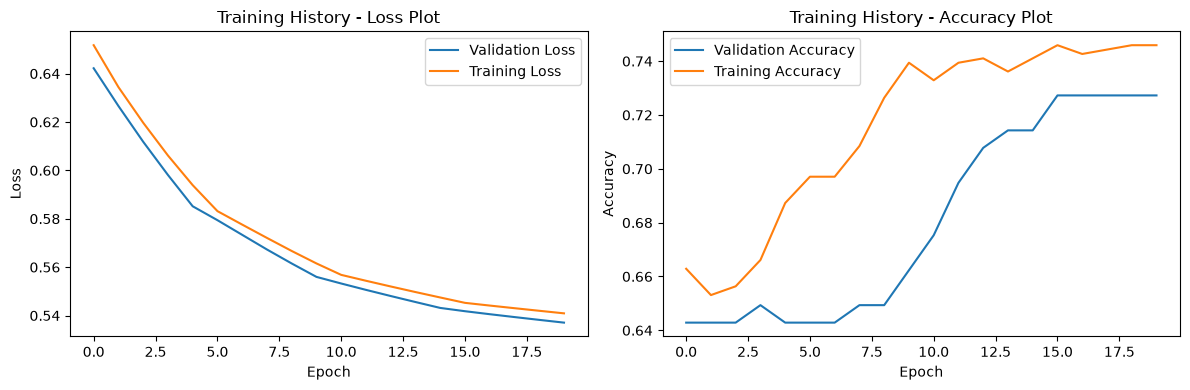

In [37]:
plot_history(history)

#### Observation
See here the kinks are clearly visible wherever the learning rate is scheduled

In [56]:
lr_schedule = ExponentialDecay(
    initial_learning_rate=0.1,
    decay_steps=50, 
    decay_rate=0.5, 
    staircase=True 
)

In [57]:
model, history = create_and_train_model(
    x_train,
    y_train,
    None,
    SGD(learning_rate=lr_schedule)
)

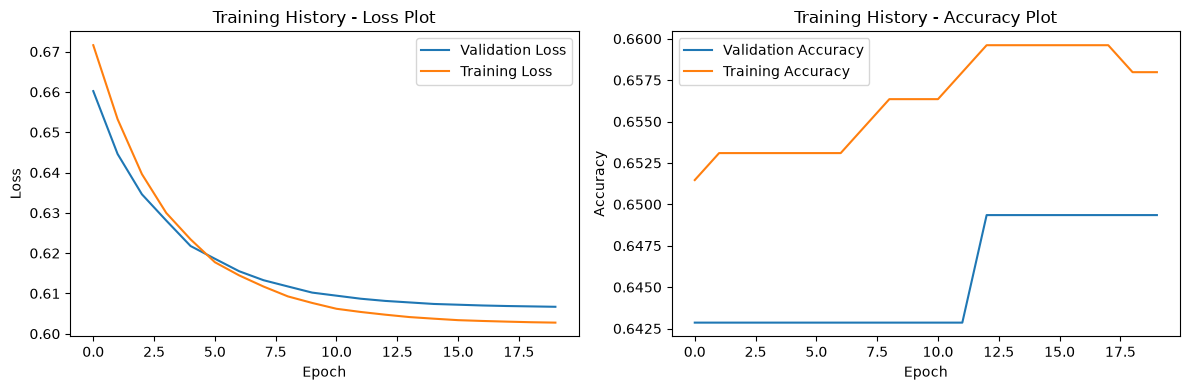

In [58]:
plot_history(history)

#### Observation
See here the kinks are vaguely visible wherever the learning rate is scheduled as there are no sudden big changes in the leanring rate

In [44]:
def cosine_decay(epoch):
    initial_lr = 0.1
    min_lr = 0.0001
    total_epochs = 20

    lr = min_lr + 0.5 * (initial_lr - min_lr) * (
        1 + np.cos(np.pi * epoch / total_epochs)
    )

    print(f"Epoch {epoch+1}: lr={lr:.6f}")

    return lr

cosine_scheduler = LearningRateScheduler(cosine_decay)

In [46]:
model, history = create_and_train_model(
    x_train,
    y_train,
    cosine_scheduler,
    SGD()
)

Epoch 1: lr=0.100000
Epoch 2: lr=0.099385
Epoch 3: lr=0.097555
Epoch 4: lr=0.094556
Epoch 5: lr=0.090460
Epoch 6: lr=0.085370
Epoch 7: lr=0.079410
Epoch 8: lr=0.072727
Epoch 9: lr=0.065485
Epoch 10: lr=0.057864
Epoch 11: lr=0.050050
Epoch 12: lr=0.042236
Epoch 13: lr=0.034615
Epoch 14: lr=0.027373
Epoch 15: lr=0.020690
Epoch 16: lr=0.014730
Epoch 17: lr=0.009640
Epoch 18: lr=0.005544
Epoch 19: lr=0.002545
Epoch 20: lr=0.000715


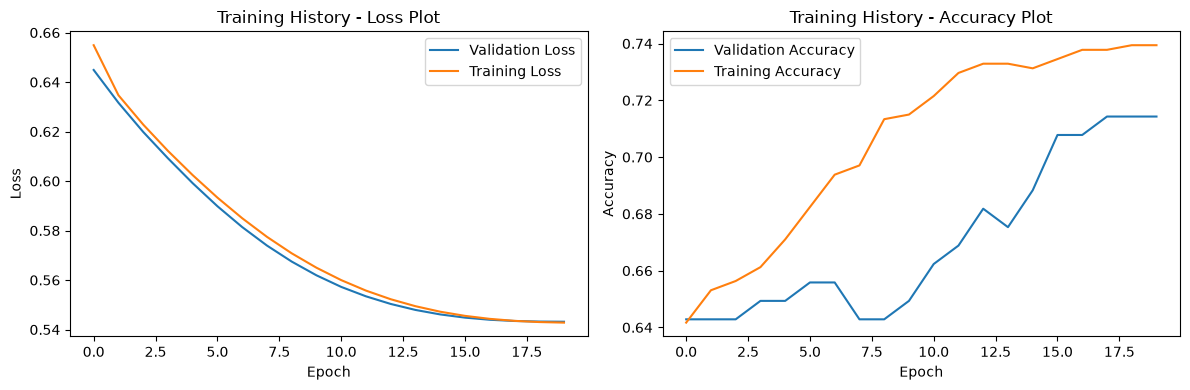

In [47]:
plot_history(history)

#### Observation
It seems smooth because of the nature of the cosine scheduling because it reduces the learning rate so closely as you can see in the model fitting output

---

# Learning Rate Scheduler Observations

## Step Decay

- Learning rate was reduced at fixed intervals, resulting in stable and predictable convergence.
- Training and validation curves were smooth with minimal oscillations.
- Achieved strong validation accuracy and loss.
- Easy to tune and interpret.

### Observation
Step Decay provided the most straightforward and stable training behavior.

---

## Exponential Decay

- Learning rate decreased continuously throughout training.
- Validation curves showed slightly more fluctuation compared to Step Decay.
- Convergence remained stable and final performance was comparable to Step Decay.
- Allowed larger updates early in training and finer updates later.

### Observation
Exponential Decay offered a smoother transition in learning rate but introduced slightly noisier training dynamics.

---

## Cosine Annealing

- Performance was highly dependent on the initial learning rate.
- With an initial learning rate of 0.01, convergence occurred too early and validation performance was lower.
- Increasing the initial learning rate to 0.1 significantly improved results.
- Produced smooth convergence and strong final validation accuracy.

### Observation
Cosine Annealing was the most sensitive to hyperparameter choice but delivered competitive results when paired with a sufficiently large initial learning rate.

---

## Overall Conclusion

- Learning rate scheduling improved training stability compared to a fixed learning rate.
- Step Decay was the most stable scheduler.
- Exponential Decay provided smooth learning rate transitions with similar performance.
- Cosine Annealing required more careful tuning but showed the best potential when configured appropriately.
- The choice of initial learning rate had a greater impact on performance than the choice of scheduler itself.